<a href="https://colab.research.google.com/github/nogalinny/telecom-x-churn-analysis/blob/main/Alura2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
# Importação dos dados

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [17]:

# Carregamento dos dados - Extração

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

df = pd.read_json(url)

df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [18]:

# Visão geral dos dados

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


,customerID,Churn,customer,phone,internet,account
count,7267,7267,7267,7267,7267,7267
unique,7267,3,891,3,129,6931
top,9995-HOTOH,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'No', 'OnlineSecurity': 'N...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
freq,1,5174,223,3495,1581,6


In [19]:
# Verificação de valores nulos

df.isnull().sum()

,0
customerID,0
Churn,0
customer,0
phone,0
internet,0
account,0


In [20]:


# Normalização de colunas alinhadas (json)

customer_df = pd.json_normalize(df['customer'])
phone_df = pd.json_normalize(df['phone'])
internet_df = pd.json_normalize(df['internet'])
account_df = pd.json_normalize(df['account'])

In [21]:
# Consolidação dos dados

df_clean = pd.concat(
    [
        df[['customerID', 'Churn']],
        customer_df,
        phone_df,
        internet_df,
        account_df
    ],
    axis=1
)

df_clean.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [22]:
# Padronização colunas e valores

# Padronizar nomes das colunas
df_clean.columns = (
    df_clean.columns
    .str.lower()
    .str.replace(' ', '_')
)

# Substituir strings vazias por NaN
df_clean.replace(" ", np.nan, inplace=True)

In [23]:

# Conversão de tipos e tratamento de inconsistências

# Converter charges.total para numérico
df_clean['charges.total'] = pd.to_numeric(
    df_clean['charges.total'],
    errors='coerce'
)

# Preencher nulos com a mediana
df_clean['charges.total'].fillna(
    df_clean['charges.total'].median(),
    inplace=True
)


/tmp/ipykernel_462/3789205399.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['charges.total'].fillna(


In [24]:

# Padronização de dados textuais

for col in df_clean.select_dtypes(include='object').columns:
    df_clean[col] = df_clean[col].str.strip().str.lower()



In [25]:

#Correção de inconsistências lógicas

cols_services = [
    'onlinesecurity', 'onlinebackup', 'deviceprotection',
    'techsupport', 'streamingtv', 'streamingmovies'
]

for col in cols_services:
    df_clean[col] = df_clean[col].replace('no internet service', 'no')


In [26]:

# Tratamento de duplicados

df_clean.drop_duplicates(inplace=True)


In [27]:
#Verificação final de qualidade

df_clean.info()
df_clean.isnull().sum()
df_clean.duplicated().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7267 non-null   object 
 1   churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   seniorcitizen     7267 non-null   int64  
 4   partner           7267 non-null   object 
 5   dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   phoneservice      7267 non-null   object 
 8   multiplelines     7267 non-null   object 
 9   internetservice   7267 non-null   object 
 10  onlinesecurity    7267 non-null   object 
 11  onlinebackup      7267 non-null   object 
 12  deviceprotection  7267 non-null   object 
 13  techsupport       7267 non-null   object 
 14  streamingtv       7267 non-null   object 
 15  streamingmovies   7267 non-null   object 
 16  contract          7267 non-null   object 


np.int64(0)

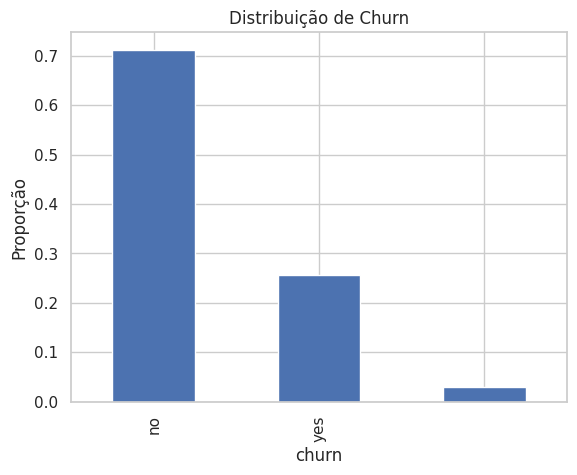

In [28]:

# Análise descritiva EDA
# Distribuição de Churn

df_clean['churn'].value_counts(normalize=True).plot(
    kind='bar',
    title='Distribuição de Churn',
    ylabel='Proporção'
)
plt.show()

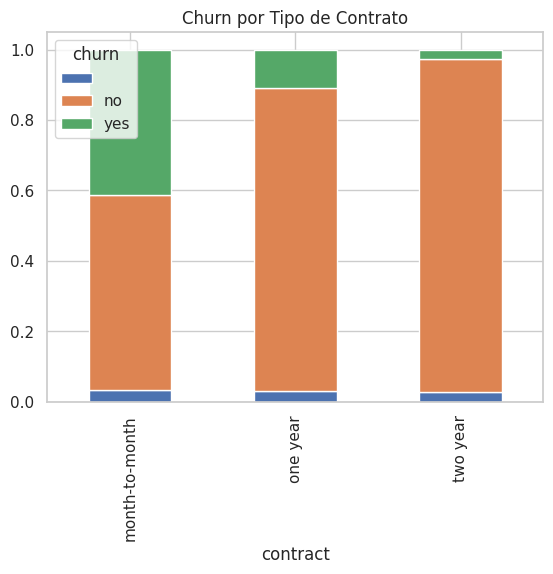

In [29]:

#Churn por tipo de contrato

churn_contract = (
    df_clean
    .groupby('contract')['churn']
    .value_counts(normalize=True)
    .unstack()
)

churn_contract.plot(
    kind='bar',
    stacked=True,
    title='Churn por Tipo de Contrato'
)
plt.show()


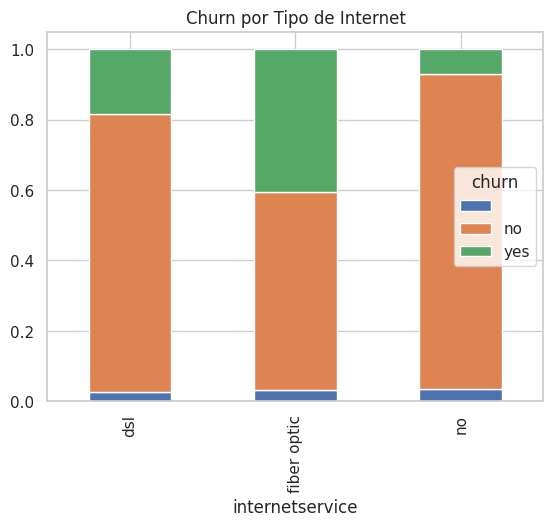

In [30]:

# Churn por tipo de internet

churn_internet = (
    df_clean
    .groupby('internetservice')['churn']
    .value_counts(normalize=True)
    .unstack()
)

churn_internet.plot(
    kind='bar',
    stacked=True,
    title='Churn por Tipo de Internet'
)
plt.show()


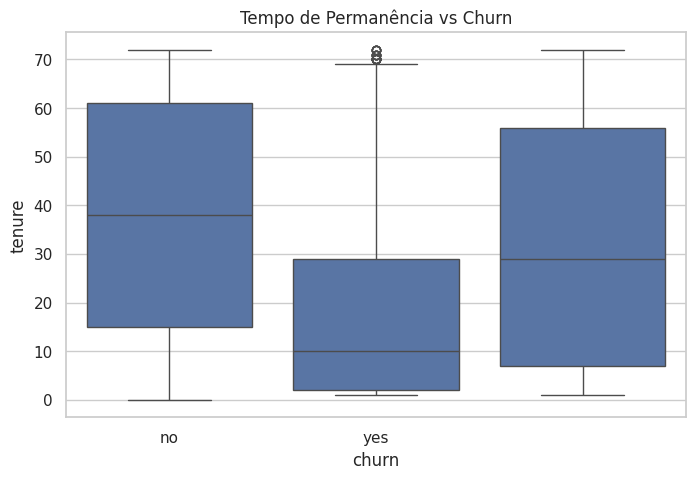

In [31]:
#Churn tempo de permanência

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_clean,
    x='churn',
    y='tenure'
)
plt.title('Tempo de Permanência vs Churn')
plt.show()


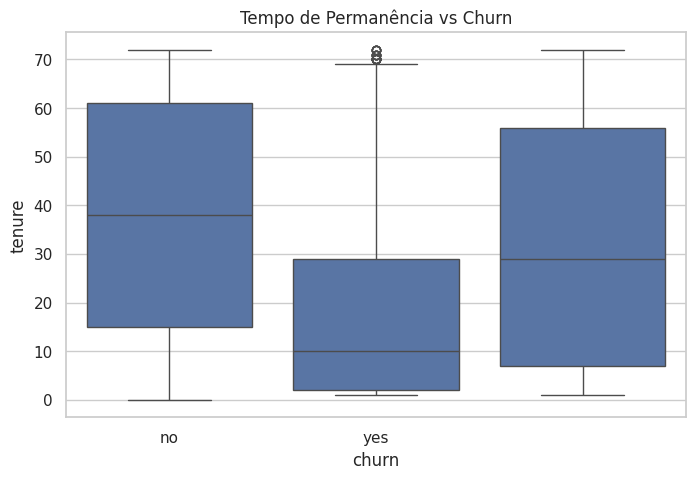

In [32]:
#Churn tempo de permanência

plt.figure(figsize=(8,5))
sns.boxplot(
    data=df_clean,
    x='churn',
    y='tenure'
)
plt.title('Tempo de Permanência vs Churn')
plt.show()


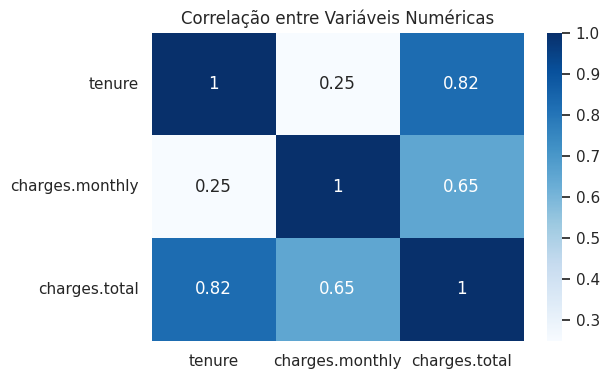

In [33]:
# Análise de correlação (variáveis numéricas)

plt.figure(figsize=(6,4))
sns.heatmap(
    df_clean[['tenure', 'charges.monthly', 'charges.total']].corr(),
    annot=True,
    cmap='Blues'
)
plt.title('Correlação entre Variáveis Numéricas')
plt.show()



In [34]:
# Remoção de colunas irrelevantes

df_model = df_clean.drop(columns=['customerid'])

df_model.head()

,churn,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,charges.monthly,charges.total
0,no,female,0,yes,yes,9,yes,no,dsl,no,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.30
1,no,male,0,no,no,9,yes,yes,dsl,no,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40
2,yes,male,0,no,no,4,yes,no,fiber optic,no,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85
3,yes,male,1,yes,no,13,yes,no,fiber optic,no,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85
4,yes,female,1,yes,no,3,yes,no,fiber optic,no,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40


In [35]:
# One-hot encoding das variáveis categóricas

df_encoded = pd.get_dummies(df_model, drop_first=True)

df_encoded.head()

,seniorcitizen,tenure,charges.monthly,charges.total,churn_no,churn_yes,gender_male,partner_yes,dependents_yes,phoneservice_yes,multiplelines_no phone service,multiplelines_yes,internetservice_fiber optic,internetservice_no,onlinesecurity_yes,onlinebackup_yes,deviceprotection_yes,techsupport_yes,streamingtv_yes,streamingmovies_yes,contract_one year,contract_two year,paperlessbilling_yes,paymentmethod_credit card (automatic),paymentmethod_electronic check,paymentmethod_mailed check
0,0,9,65.6,593.30,True,False,False,True,True,True,False,False,False,False,False,True,False,True,True,False,True,False,True,False,False,True
1,0,9,59.9,542.40,True,False,True,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,False,True,True,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,False,True,True,True,False,True,False,False,True,False,False,True,True,False,True,True,False,False,True,False,True,False
4,1,3,83.9,267.40,False,True,False,True,False,True,False,False,True,False,False,False,False,True,True,False,False,False,True,False,False,True


In [36]:
# Separação de target e features

X = df_encoded.drop(columns=['churn_yes'])
y = df_encoded['churn_yes']

False → cliente não saiu

True → cliente saiu

O parâmetro normalize=True faz o cálculo da proporção em vez da contagem.

False - Clientes que permaneceram 74,28%
True - Clientes que não permaneceram 25,71%

In [37]:
# Proporção de churn

y.value_counts(normalize=True)

,proportion
churn_yes,
False,0.74281
True,0.25719


A maioria dos clientes permanece na empresa.

A taxa de churn é aproximadamente 25,7%

1 em cada 4 clientes cancela o serviço.

Isso já indica um problema relevante de retenção de clientes.

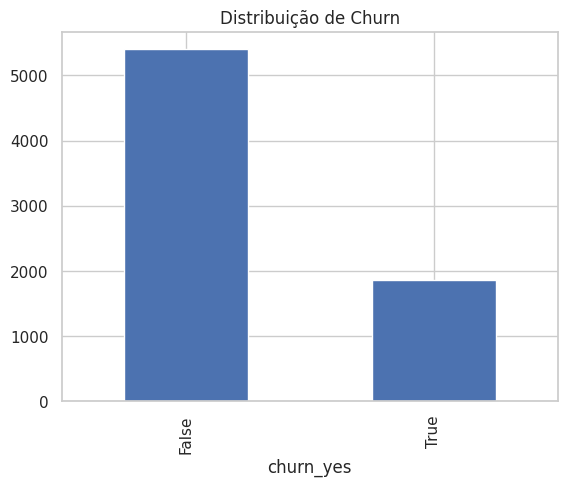

In [38]:
y.value_counts().plot(kind='bar', title='Distribuição de Churn')
plt.show()

False - Clientes que não cancelaram True - Clientes que cancelaram
O dataset apresenta desbalanceamentos de classes, distribuição aproximada: 74% ativos 26% cancelados.

Problema - Algoritmos podem favorecer a classe majoritária (False) ter dificuldade de prever corretamente.

Devido ao desbalanceamento identificado na variável target churn, será necessário aplicar técnicas de balanceamento, como SMOTE, antes do treinamento dos modelos de classificação, para evitar viés em direção à classe majoritária.


In [39]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X, y)

print(y_resampled.value_counts())

churn_yes
False    5398
True     5398
Name: count, dtype: int64


False - Nao saiu True - Saiu
50% clientes ficaram
50% clientes saíram

Antes tinha False 5174 e True 1869

Ou seja, dataset desbalanceado, depois aplicado smote teve outro resultado.

O balanceamento garante que o modelo de Machine Learning não favoreça apenas a classe majoritária, melhorando a capacidade de prever clientes que podem cancelar o serviço.

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_resampled)

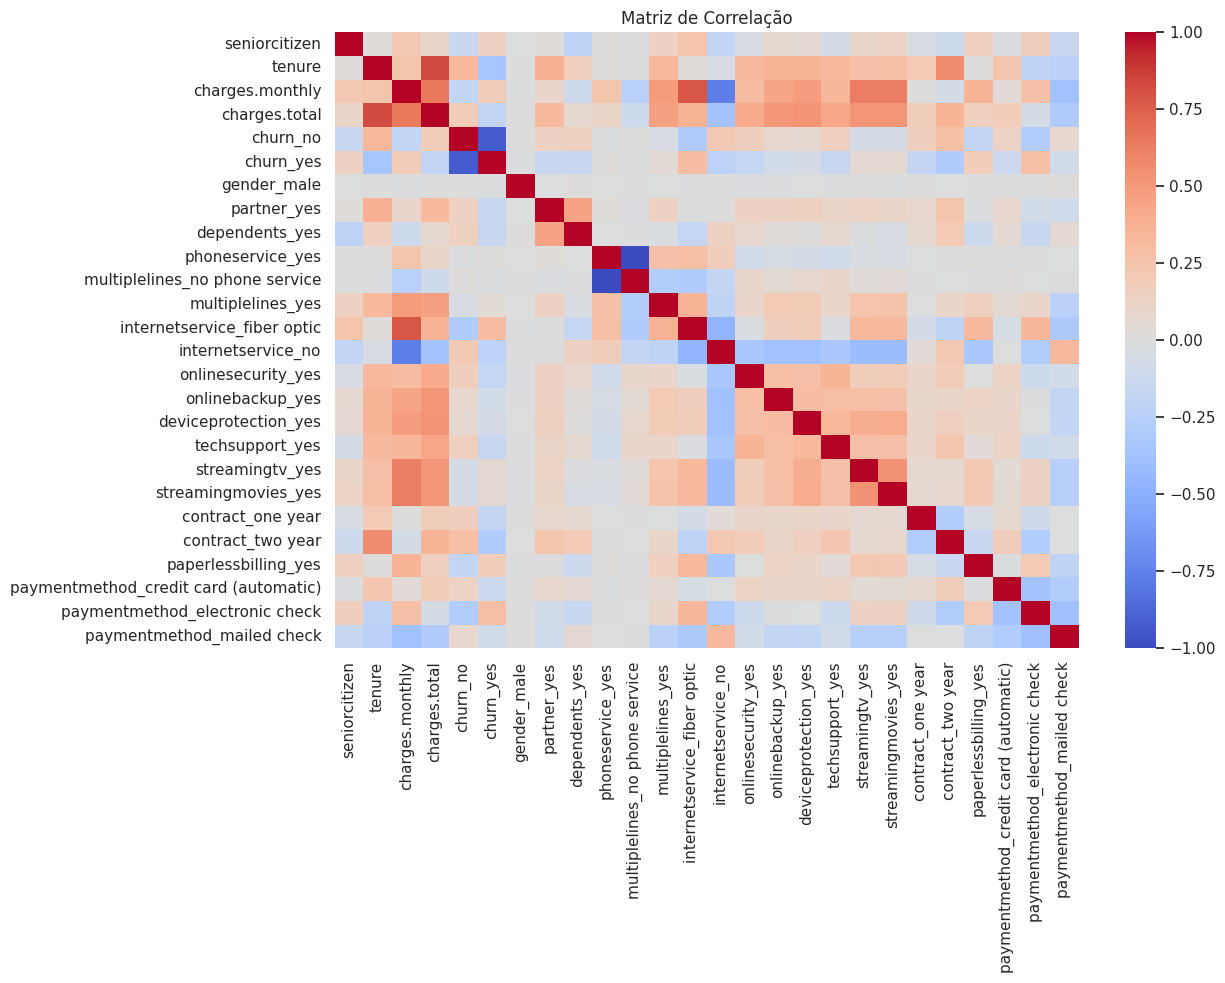

In [41]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df_encoded.corr(),
    cmap='coolwarm'
)

plt.title("Matriz de Correlação")
plt.show()

A matriz de correlação indica que o churn está fortemente associado ao tipo de contrato, tempo de permanência e serviços adicionais. Clientes com contratos de longo prazo e maior tempo de permanência apresentam menor probabilidade de cancelamento, enquanto clientes com internet de fibra óptica e mensalidades mais altas demonstram maior propensão ao churn.

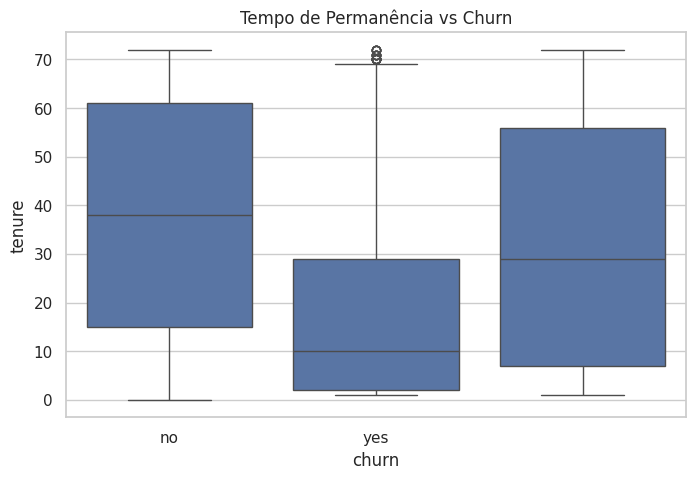

In [42]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x='churn',
    y='tenure'
)

plt.title("Tempo de Permanência vs Churn")
plt.show()

Esse cálculo mostra a proporção de clientes que permaneceram vs os que cancelaram.

False (0.74281) → clientes que não cancelaram → 74,28%

True (0.25719) → clientes que cancelaram → 25,71%

Interpretação

Isso significa que:

A maioria dos clientes permanece na empresa

Aproximadamente 1 em cada 4 clientes cancela o serviço

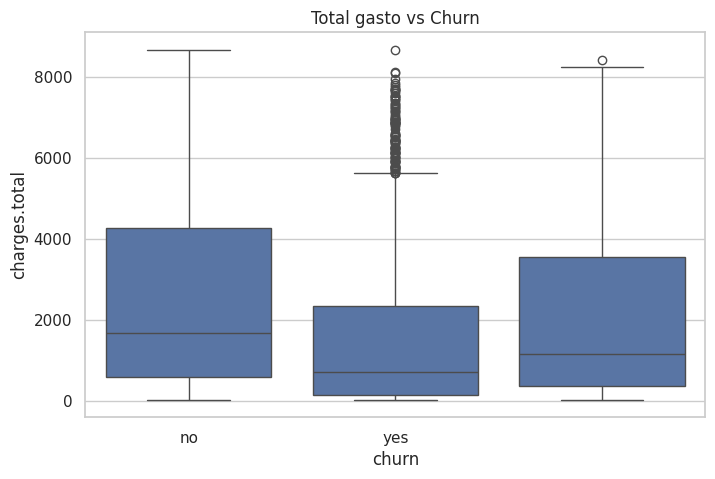

In [43]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x='churn',
    y='charges.total'
)

plt.title("Total gasto vs Churn")
plt.show()

barra maior → clientes que permaneceram

barra menor → clientes que cancelaram

Isso confirma que:

A evasão representa uma parcela menor da base.

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [45]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression()

model_log.fit(X_train, y_train)

y_pred_log = model_log.predict(X_test)

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [47]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

Acurácia: 0.9777777777777777
              precision    recall  f1-score   support

       False       1.00      0.96      0.98      1060
        True       0.96      1.00      0.98      1100

    accuracy                           0.98      2160
   macro avg       0.98      0.98      0.98      2160
weighted avg       0.98      0.98      0.98      2160



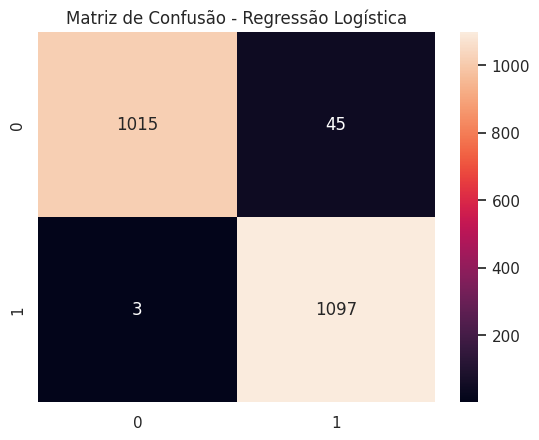

In [48]:
print("Acurácia:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d')
plt.title("Matriz de Confusão - Regressão Logística")
plt.show()

Acurácia: 0.9731481481481481
              precision    recall  f1-score   support

       False       0.99      0.96      0.97      1060
        True       0.96      0.99      0.97      1100

    accuracy                           0.97      2160
   macro avg       0.97      0.97      0.97      2160
weighted avg       0.97      0.97      0.97      2160



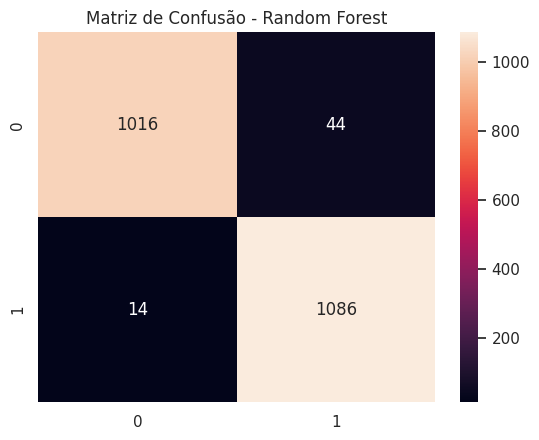

In [49]:
print("Acurácia:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Matriz de Confusão - Random Forest")
plt.show()

In [50]:
importances = rf.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    'variavel': features,
    'importancia': importances
}).sort_values(by='importancia', ascending=False)

importance_df.head(10)

,variavel,importancia
4,churn_no,0.646103
23,paymentmethod_electronic check,0.068650
1,tenure,0.054414
3,charges.total,0.042842
2,charges.monthly,0.035987
11,internetservice_fiber optic,0.035225
20,contract_two year,0.027958
21,paperlessbilling_yes,0.019725
12,internetservice_no,0.007320
19,contract_one year,0.006592


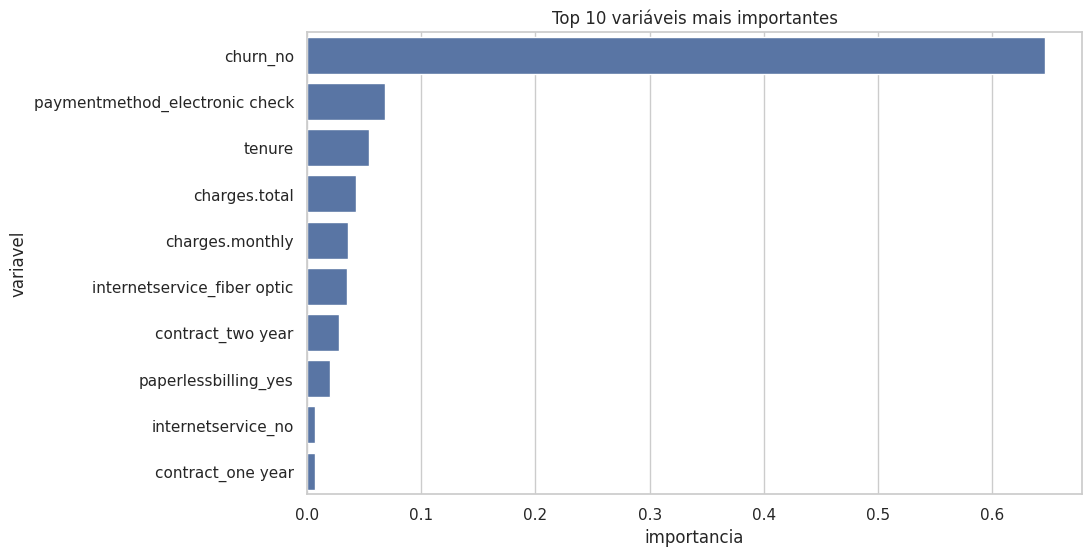

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance_df.head(10),
    x='importancia',
    y='variavel'
)

plt.title("Top 10 variáveis mais importantes")
plt.show()